In [1]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

horse_colic = fetch_ucirepo(id=47)

X = horse_colic.data.features.copy()
y = horse_colic.data.targets.copy()

target_col = y.columns[0]

data = pd.concat([X, y], axis=1)

print('Размер датасета:', data.shape)
print('Целевой признак:', target_col)

data.head()

Размер датасета: (368, 28)
Целевой признак: surgical_lesion


,surgery,age,hospital_number,rectal_temperature,pulse,respiratory_rate,temperature_of_extremities,peripheral_pulse,mucous_membranes,capillary_refill_time,...,packed_cell_volume,total_protein,abdominocentesis_appearance,abdominocentesis_total_protein,outcome,lesion_site,lesion_type,lesion_subtype,cp_data,surgical_lesion
0,2.0,1,530101,38.5,66.0,28.0,3.0,3.0,NaN,2.0,...,45.0,8.4,NaN,NaN,2.0,11300,0,0,2,2
1,1.0,1,534817,39.2,88.0,20.0,NaN,NaN,4.0,1.0,...,50.0,85.0,2.0,2.0,3.0,2208,0,0,2,2
2,2.0,1,530334,38.3,40.0,24.0,1.0,1.0,3.0,1.0,...,33.0,6.7,NaN,NaN,1.0,0,0,0,1,2
3,1.0,9,5290409,39.1,164.0,84.0,4.0,1.0,6.0,2.0,...,48.0,7.2,3.0,5.3,2.0,2208,0,0,1,1
4,2.0,1,530255,37.3,104.0,35.0,NaN,NaN,6.0,2.0,...,74.0,7.4,NaN,NaN,2.0,4300,0,0,2,2


## 1. Гистограмма

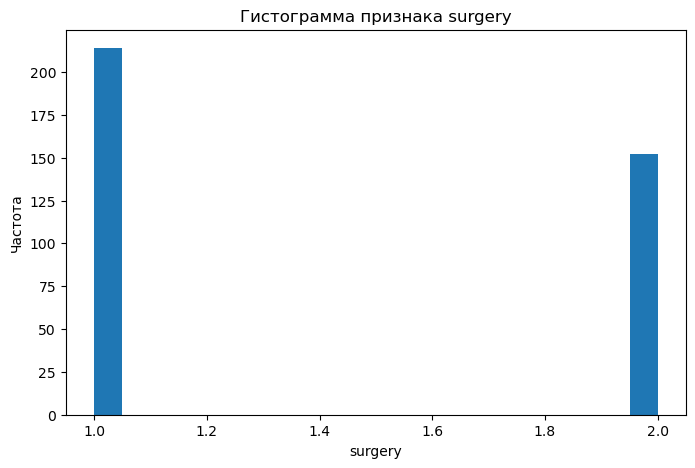

In [2]:
numeric_cols = data.select_dtypes(include=np.number).columns

selected_col = numeric_cols[0]

plt.figure(figsize=(8, 5))

plt.hist(data[selected_col].dropna(), bins=20)

plt.title(f'Гистограмма признака {selected_col}')
plt.xlabel(selected_col)
plt.ylabel('Частота')

plt.show()

## 2. Диаграмма рассеяния


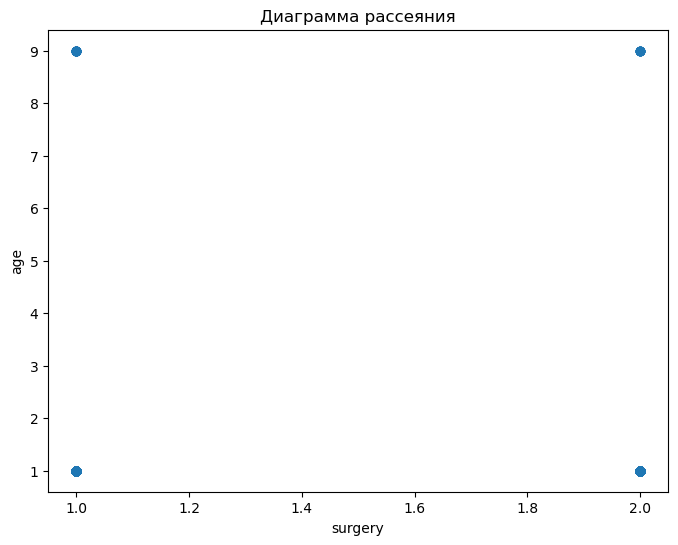

In [3]:
if len(numeric_cols) >= 2:

    plt.figure(figsize=(8, 6))

    plt.scatter(
        data[numeric_cols[0]],
        data[numeric_cols[1]]
    )

    plt.xlabel(numeric_cols[0])
    plt.ylabel(numeric_cols[1])

    plt.title('Диаграмма рассеяния')

    plt.show()

## 3. Круговая диаграмма

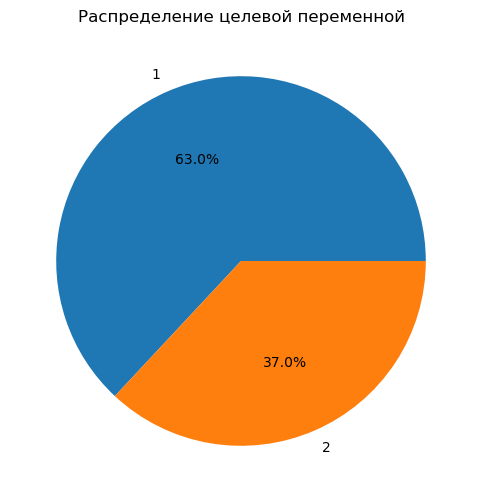

In [4]:
class_counts = data[target_col].value_counts()

plt.figure(figsize=(6, 6))

plt.pie(
    class_counts,
    labels=class_counts.index,
    autopct='%1.1f%%'
)

plt.title('Распределение целевой переменной')

plt.show()

## 4. Столбчатая диаграмма

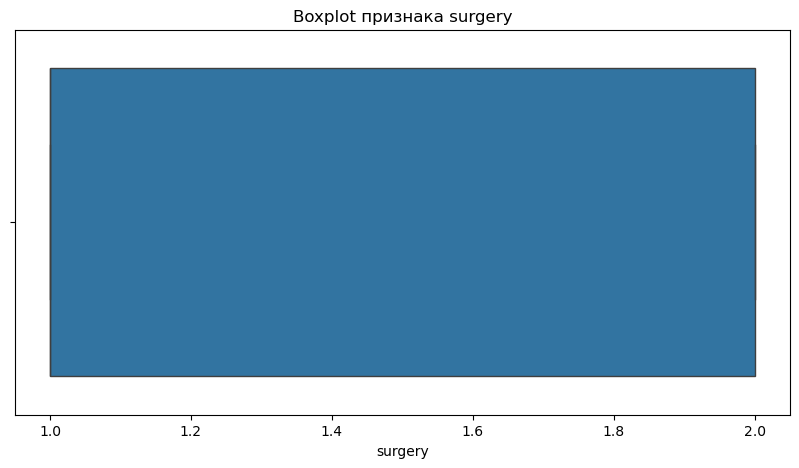

In [5]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=data[selected_col])

plt.title(f'Boxplot признака {selected_col}')

plt.show()